In [275]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data= pd.read_csv('patient_data.csv')

# Clean column names
data.columns = data.columns.str.strip()

data.rename(columns={'C': 'Gender'}, inplace=True)

data.head()

,Gender,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,Male,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
1,Female,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
2,Male,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
3,Female,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
4,Male,51-64,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)


In [276]:
nominal_features=['Gender', 'History', 'Patient', 'TakeMedication', 'BreathShortness', 'VisualChanges', 'NoseBleeding', 'ControlledDiet']
                  
ordinal_features=[f for f in data.columns if f not in nominal_features]
ordinal_features.remove('Stages')
print(nominal_features)
print(ordinal_features)

['Gender', 'History', 'Patient', 'TakeMedication', 'BreathShortness', 'VisualChanges', 'NoseBleeding', 'ControlledDiet']
['Age', 'Severity', 'Whendiagnoused', 'Systolic', 'Diastolic']


In [277]:
data.isnull().sum()

Gender             0
Age                0
History            0
Patient            0
TakeMedication     0
Severity           0
BreathShortness    0
VisualChanges      0
NoseBleeding       0
Whendiagnoused     0
Systolic           0
Diastolic          0
ControlledDiet     0
Stages             0
dtype: int64

In [278]:
# Encode nominal features
for col in nominal_features:
    if set(data[col].unique()) == {'Yes', 'No'}:
        data[col] = data[col].map({'No': 0, 'Yes': 1})
        
    elif col == 'Gender':
        data[col] = data[col].map({'Male': 0, 'Female': 1})


# Ordinal mappings
data['Age'] = data['Age'].map({
    '18-34': 1,
    '35-50': 2,
    '51-64': 3,
    '65+': 4
})

# 🔥 Changed replace() → map() (removes warning)
data['Severity'] = data['Severity'].map({
    'Mild': 0,
    'Moderate': 1,
    'Sever': 2   # keeping your dataset spelling
})

data['Whendiagnoused'] = data['Whendiagnoused'].map({
    '<1 Year': 1,
    '1 - 5 Years': 2,
    '>5 Years': 3
})

data['Systolic'] = data['Systolic'].map({
    '100 - 110': 0,
    '111 - 120': 1,
    '121 - 130': 2,
    '130+': 3
})

data['Diastolic'] = data['Diastolic'].map({
    '70 - 80': 0,
    '81 - 90': 1,
    '91 - 100': 2,
    '100+': 3
})

data['Stages'] = data['Stages'].map({
    'NORMAL': 0,
    'HYPERTENSION (Stage-1)': 1,
    'HYPERTENSION (Stage-2)': 2,
    'HYPERTENSIVE CRISIS': 3
})

In [279]:
print(data.columns)

Index(['Gender', 'Age', 'History', 'Patient', 'TakeMedication', 'Severity',
       'BreathShortness', 'VisualChanges', 'NoseBleeding', 'Whendiagnoused',
       'Systolic', 'Diastolic', 'ControlledDiet', 'Stages'],
      dtype='object')


In [280]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()   # ← you missed '='

data[ordinal_features] = scaler.fit_transform(data[ordinal_features])

In [281]:
print(data['Severity'].unique())

[0.  1.  0.5]


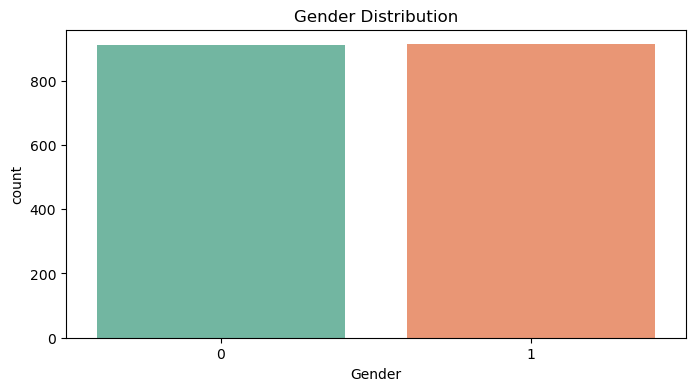

In [282]:
plt.figure(figsize=(8,4))
sns.countplot(data=data, x="Gender", hue="Gender", palette="Set2", legend=False)
plt.title("Gender Distribution")
plt.show()

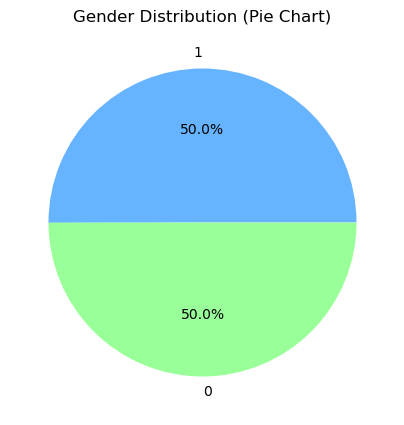

In [283]:
#Pie chart for Gender
data['Gender'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(5,5), colors=['#66b3ff','#99ff99'])
plt.title("Gender Distribution (Pie Chart)")
plt.ylabel("")
plt.show()

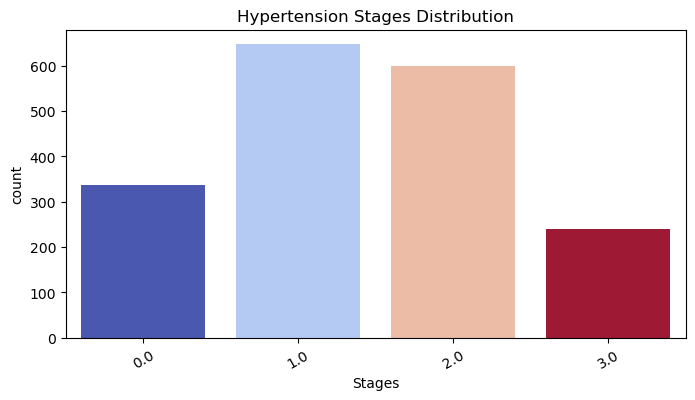

In [284]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=data,
    x="Stages",
    hue="Stages",
    palette="coolwarm",
    legend=False
)

plt.title("Hypertension Stages Distribution")
plt.xticks(rotation=30)
plt.show()

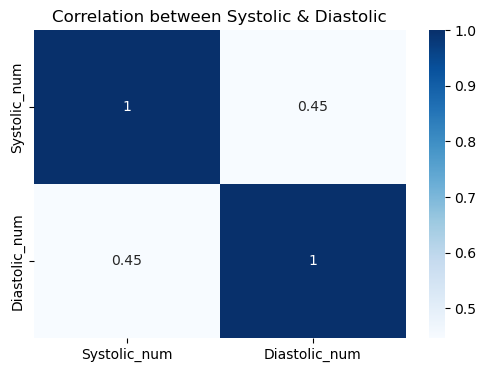

In [285]:
# Heatmap on encoded numeric BP only (after midpoint conversion)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

def range_to_midpoint(val):
    if isinstance(val, str):
        if "-" in val:
            start, end = val.split("-")
            return (int(start.strip()) + int(end.strip())) / 2
        elif "+" in val:
            return int(val.replace("+", "").strip())
    elif isinstance(val, (int, float)):
        return val   # already numeric
    return np.nan


data['Systolic_num'] = data['Systolic'].apply(range_to_midpoint)
data['Diastolic_num'] = data['Diastolic'].apply(range_to_midpoint)

plt.figure(figsize=(6,4))
sns.heatmap(
    data[['Systolic_num', 'Diastolic_num']].corr(),
    annot=True,
    cmap="Blues"
)
plt.title("Correlation between Systolic & Diastolic")
plt.show()

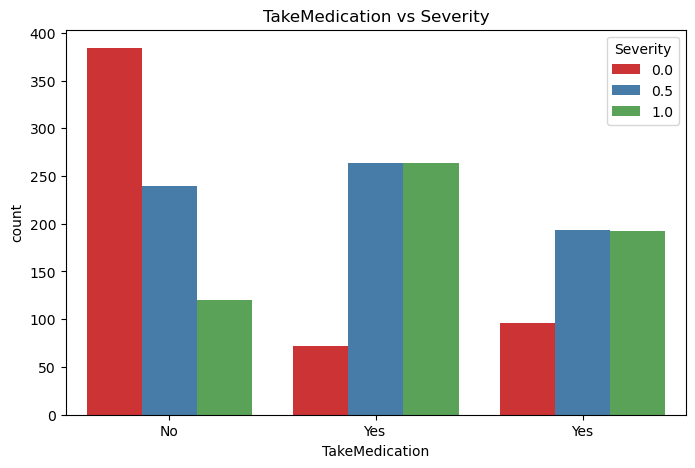

In [286]:
# Relationship: TakeMedication vs Severity
plt.figure(figsize=(8,5))
sns.countplot(data=data, x="TakeMedication", hue="Severity", palette="Set1")
plt.title("TakeMedication vs Severity")
plt.show()

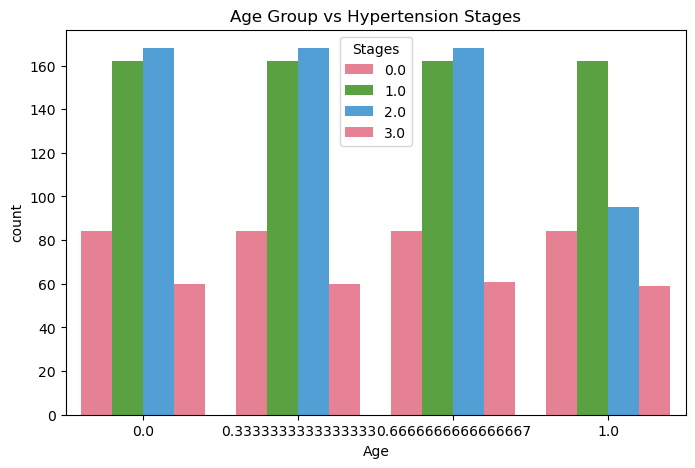

In [287]:
# Age group vs Stages
plt.figure(figsize=(8,5))
sns.countplot(data=data, x="Age", hue="Stages", palette="husl")
plt.title("Age Group vs Hypertension Stages")
plt.show()

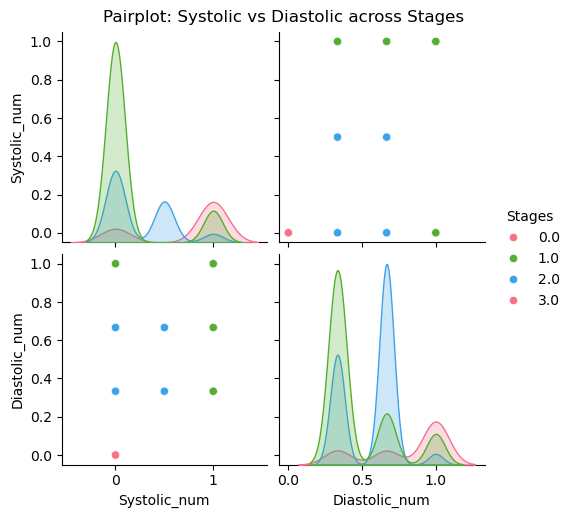

In [288]:
sns.pairplot(
    data[['Systolic_num', 'Diastolic_num', 'Stages']],
    hue='Stages',
    diag_kind="kde",
    palette="husl"
)

plt.suptitle("Pairplot: Systolic vs Diastolic across Stages", y=1.02)
plt.show()

In [289]:
# Encode remaining Yes/No columns safely

yes_no_cols = ['TakeMedication', 'NoseBleeding']

for col in yes_no_cols:
    data[col] = data[col].map({'No': 0, 'Yes': 1})

In [290]:
data = data.dropna(subset=['Stages'])

In [291]:
data = data.drop(['Systolic', 'Diastolic'], axis=1)

In [292]:
for col in ['TakeMedication', 'NoseBleeding']:
    data[col] = data[col].fillna(data[col].mode()[0])

In [293]:
for col in ['Systolic_num', 'Diastolic_num']:
    data[col] = data[col].fillna(data[col].mean())

In [294]:
from sklearn.model_selection import train_test_split
x=data.drop('Stages', axis=1)
y=data['Stages']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [295]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy={}

In [296]:
from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression(max_iter=1000, random_state=42)

logistic_regression.fit(X_train, y_train)

y_pred = logistic_regression.predict(X_test)

print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['Logistic Regression'] = accuracy_score(y_test, y_pred)

Logistic Regression:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        67
         1.0       1.00      1.00      1.00       132
         2.0       1.00      1.00      1.00       119
         3.0       1.00      1.00      1.00        47

    accuracy                           1.00       365
   macro avg       1.00      1.00      1.00       365
weighted avg       1.00      1.00      1.00       365

Confusion Matrix:
 [[ 67   0   0   0]
 [  0 132   0   0]
 [  0   0 119   0]
 [  0   0   0  47]]


In [297]:
decision_tree = DecisionTreeClassifier()

decision_tree.fit(X_train, y_train)

y_pred = decision_tree.predict(X_test)

print("Decision Tree:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['Decision Tree'] = accuracy_score(y_test, y_pred)

Decision Tree:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        67
         1.0       1.00      1.00      1.00       132
         2.0       1.00      1.00      1.00       119
         3.0       1.00      1.00      1.00        47

    accuracy                           1.00       365
   macro avg       1.00      1.00      1.00       365
weighted avg       1.00      1.00      1.00       365

Confusion Matrix:
 [[ 67   0   0   0]
 [  0 132   0   0]
 [  0   0 119   0]
 [  0   0   0  47]]


In [298]:
randomforest=RandomForestClassifier()
randomforest.fit(X_train, y_train)
y_pred = randomforest.predict(X_test)
print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))
accuracy['Random Forest']=accuracy_score(y_test, y_pred)

Random Forest:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        67
         1.0       1.00      1.00      1.00       132
         2.0       1.00      1.00      1.00       119
         3.0       1.00      1.00      1.00        47

    accuracy                           1.00       365
   macro avg       1.00      1.00      1.00       365
weighted avg       1.00      1.00      1.00       365

Confusion Matrix: 
 [[ 67   0   0   0]
 [  0 132   0   0]
 [  0   0 119   0]
 [  0   0   0  47]]


In [299]:
svm=SVC()
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
print("SVM:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report: \n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
accuracy ['SVM']=accuracy_score(y_test, y_pred)

SVM:
Accuracy: 1.0
Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        67
         1.0       1.00      1.00      1.00       132
         2.0       1.00      1.00      1.00       119
         3.0       1.00      1.00      1.00        47

    accuracy                           1.00       365
   macro avg       1.00      1.00      1.00       365
weighted avg       1.00      1.00      1.00       365

Confusion Matrix:
 [[ 67   0   0   0]
 [  0 132   0   0]
 [  0   0 119   0]
 [  0   0   0  47]]


In [300]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("KNN:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

accuracy['KNN'] = accuracy_score(y_test, y_pred)

KNN:
Accuracy: 0.9863013698630136
Classification Report:
               precision    recall  f1-score   support

         0.0       0.93      1.00      0.96        67
         1.0       1.00      0.96      0.98       132
         2.0       1.00      1.00      1.00       119
         3.0       1.00      1.00      1.00        47

    accuracy                           0.99       365
   macro avg       0.98      0.99      0.99       365
weighted avg       0.99      0.99      0.99       365

Confusion Matrix:
 [[ 67   0   0   0]
 [  5 127   0   0]
 [  0   0 119   0]
 [  0   0   0  47]]


In [301]:
RC=RidgeClassifier()
RC.fit(X_train, y_train)
y_pred = RC.predict(X_test)
print("RidgeClassifier:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report: \n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
accuracy['RidgeClassifier']=accuracy_score(y_test, y_pred)

RidgeClassifier:
Accuracy: 0.9232876712328767
Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      0.58      0.74        67
         1.0       0.82      1.00      0.90       132
         2.0       1.00      1.00      1.00       119
         3.0       1.00      1.00      1.00        47

    accuracy                           0.92       365
   macro avg       0.96      0.90      0.91       365
weighted avg       0.94      0.92      0.92       365

Confusion Matrix:
 [[ 39  28   0   0]
 [  0 132   0   0]
 [  0   0 119   0]
 [  0   0   0  47]]


In [302]:
naive_bayes=GaussianNB()
naive_bayes.fit(X_train, y_train)
y_pred= naive_bayes.predict(X_test)
print("Naive Bayes:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report: \n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
accuracy ['Naive Bayes']=accuracy_score(y_test, y_pred)

Naive Bayes:
Accuracy: 1.0
Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        67
         1.0       1.00      1.00      1.00       132
         2.0       1.00      1.00      1.00       119
         3.0       1.00      1.00      1.00        47

    accuracy                           1.00       365
   macro avg       1.00      1.00      1.00       365
weighted avg       1.00      1.00      1.00       365

Confusion Matrix:
 [[ 67   0   0   0]
 [  0 132   0   0]
 [  0   0 119   0]
 [  0   0   0  47]]


In [303]:
import joblib

# Save model
joblib.dump(logistic_regression, "logistic_regression_model.pkl")

print("Model saved as logistic_regression_model.pkl")

Model saved as logistic_regression_model.pkl
